# Convolutional Neural Networks

## Preliminaries

In this practical session you will implement and train several Convolutional Neural Networks (CNNs) using the Keras framework with a Tensorflow backend. If you are not already familiar with Keras, you can go over the [following tutorial](https://github.com/tueimage/essential-skills/blob/master/keras.md). More detailed information on the different functionalities can be found in the [Keras library documentation](https://keras.io/). 

Note that for this set of exercise CPU-only Tensorflow, which you should already have installed, is sufficient (i.e. GPU-support is not required but it will make your experiments run faster). 

You are also required to use the `gryds` package for data augmentation that you can install directly from git: `pip install git+https://github.com/tueimage/gryds/`.

You also have to install the Keras deep learning framework (if you have not done so already) by running `conda install keras`. Note that there are two implementations of Keras, one from https://keras.io/ and another one that ships with Tensorflow. Here we use the former. 

## MNIST
We will first train a simple CNN to classify handwritten digits using the MNIST dataset. This dataset is often referred to as the "Hello world!" example of deep learning because it can be used to quickly illustrate a small neural network in action (and obtain a decent classification accuracy in the process). More information on it can be found [here](http://yann.lecun.com/exdb/mnist/).

First, let's load the dataset and visualize some images.

2025-10-07 11:42:40.209041: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


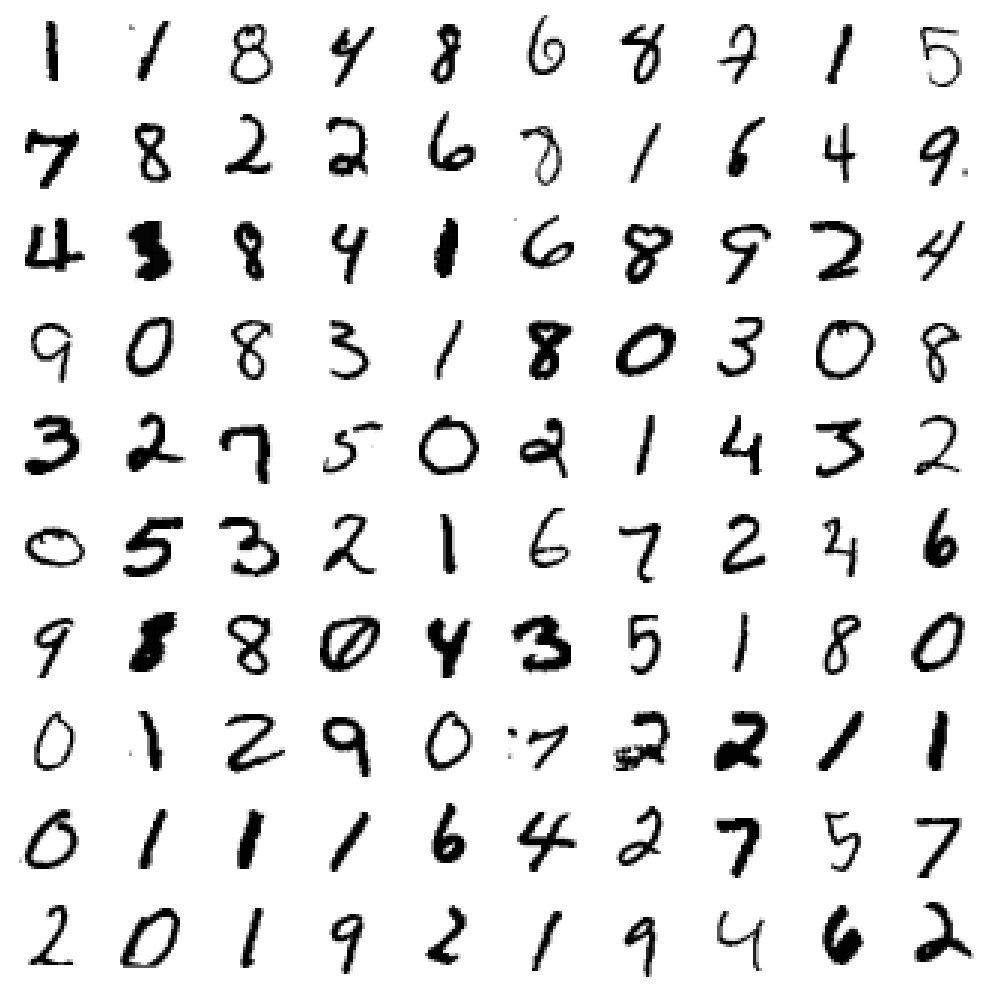

In [1]:
# disable gpu for testing
#import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.utils import to_categorical

# load the MNIST the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# scale the image intensities to the 0-1 range
x_train = (x_train / 255.0).astype(np.float32)
x_test = (x_test / 255.0).astype(np.float32)

# convert the data to channel-last
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# convert the labels to one-hot encoded
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

def plot_images(images, dim=(10, 10), figsize=(10, 10), title=''):
    
    plt.figure(figsize=figsize)
    
    for i in range(images.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        plt.imshow(images[i], interpolation='nearest', cmap='gray_r')
        plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle(title)
    plt.show()
    
plot_images(x_train[np.random.randint(0, x_train.shape[0], size=100)].reshape(100, 28, 28))

The MNIST classification task is quite simple: given an image, predict the digit that it contains. Thus, this is a 10-class classification problem.

Let's define a simple network for the handwritten digit classification.

In [2]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

Compile and train the network (note that this could take a while).

In [3]:
from keras.losses import categorical_crossentropy
from keras.optimizers import Adam

model.compile(loss=categorical_crossentropy, optimizer=Adam(), metrics=['accuracy'])

model.fit(x_train, y_train,
          batch_size=128,
          epochs=12,
          verbose=1,
          validation_data=(x_test, y_test))

score = model.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 122ms/step - accuracy: 0.9303 - loss: 0.2315 - val_accuracy: 0.9841 - val_loss: 0.0484
Epoch 2/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 144ms/step - accuracy: 0.9759 - loss: 0.0809 - val_accuracy: 0.9867 - val_loss: 0.0386
Epoch 3/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - accuracy: 0.9808 - loss: 0.0619 - val_accuracy: 0.9894 - val_loss: 0.0325
Epoch 4/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 123ms/step - accuracy: 0.9845 - loss: 0.0499 - val_accuracy: 0.9899 - val_loss: 0.0290
Epoch 5/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 123ms/step - accuracy: 0.9863 - loss: 0.0431 - val_accuracy: 0.9899 - val_loss: 0.0300
Epoch 6/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 123ms/step - accuracy: 0.9882 - loss: 0.0387 - val_accuracy: 0.9895 - val_loss: 0.0338
Epoch 7/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.9896 - loss: 0.0333 - val_accuracy: 0.9908 - val_loss: 0.0276
Epoch 8/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 137ms/step - accuracy: 0.9908 - loss: 0

Now that the model is trained, we can evaluate its performance on the independent test dataset.

In [4]:
score = model.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.03060019202530384
Test accuracy: 0.991599977016449


## U-Net
The U-Net convolutional neural network architecture was first developed for biomedical image segmentation and is to this day one of the most widely used methods for image segmentation. The details of the architecture can be found in the [original paper](https://arxiv.org/abs/1505.04597). In this practical we will build and train a U-Net network that is able to segment blood vessels in retinal images. 

### Loading and visualizing the data
The data for this task is taken from the [DRIVE](https://www.kaggle.com/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction) database. It consists of photographs of the retina, where the goal is to segment the blood vessels within. The dataset has a total of 40 photographs, divided in 20 images for training and 20 for testing. The images corresponding to the DRIVE test set can be found [here](https://drive.google.com/file/d/1Enau6gb_BtPKCg1Yt5MZIIM18pfVEhxQ/view?usp=sharing).

Let's load the training set and visualize an image with the corresponding blood vessel segmentation. For training we will divide the data in a training and a validation set to monitor the model during training.

(20, 584, 565, 3)


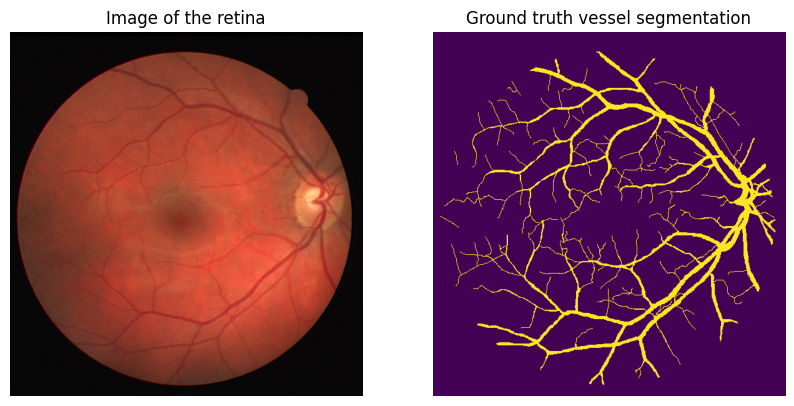

(16, 584, 565, 3)
(16, 584, 565, 1)
(16, 584, 565, 1)
(4, 584, 565, 3)
(4, 584, 565, 1)
(4, 584, 565, 1)


In [5]:
%matplotlib inline
import sys
sys.path.append('code/')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from glob import glob
from unet_utils import load_data

# location of the DRIVE dataset
data_folder = 'data/DRIVE/'
train_paths = glob(data_folder + 'training/images/*.tif')
images, masks, segmentations = load_data(train_paths)

# print the shape of image dataset
print(images.shape)

plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.title("Image of the retina")
plt.axis('off')
plt.imshow(images[0])

plt.subplot(1, 2, 2)
plt.title("Ground truth vessel segmentation")
plt.axis('off')
plt.imshow(segmentations[0][:, :, 0])

plt.show()

# divide in training and validation
train_images, val_images, train_masks, val_masks, train_segmentations, val_segmentations = train_test_split(
    images, masks, segmentations, test_size=0.2, random_state=7)

# print the shape of the training and valudation datasets
print(train_images.shape)
print(train_masks.shape)
print(train_segmentations.shape)
print(val_images.shape)
print(val_masks.shape)
print(val_segmentations.shape)

### Training a U-Net model

You are already provided with implementation of the U-Net architecture in `unet_model.py`. This is a modular implementation and can be used to generate U-Net architectures with a variety of hyperparameters such as depth and number of feature maps. Before using the model, examine the code and documentation and make sure that you understand all the details.

We will train a U-Net model using smaller patches extracted from the training images. Training the images on smaller patches requires less computation power and results in a more varied training dataset (it has the effect of data augmentation by image translation). Because a U-Net is a fully convolutional network it can be evaluated on inputs of different size (the output size will change according to the input size). Thus, although the model will be trained on smaller patches it can still be used to segment larger images with one pass through the model. 


(16, 32, 32, 3)


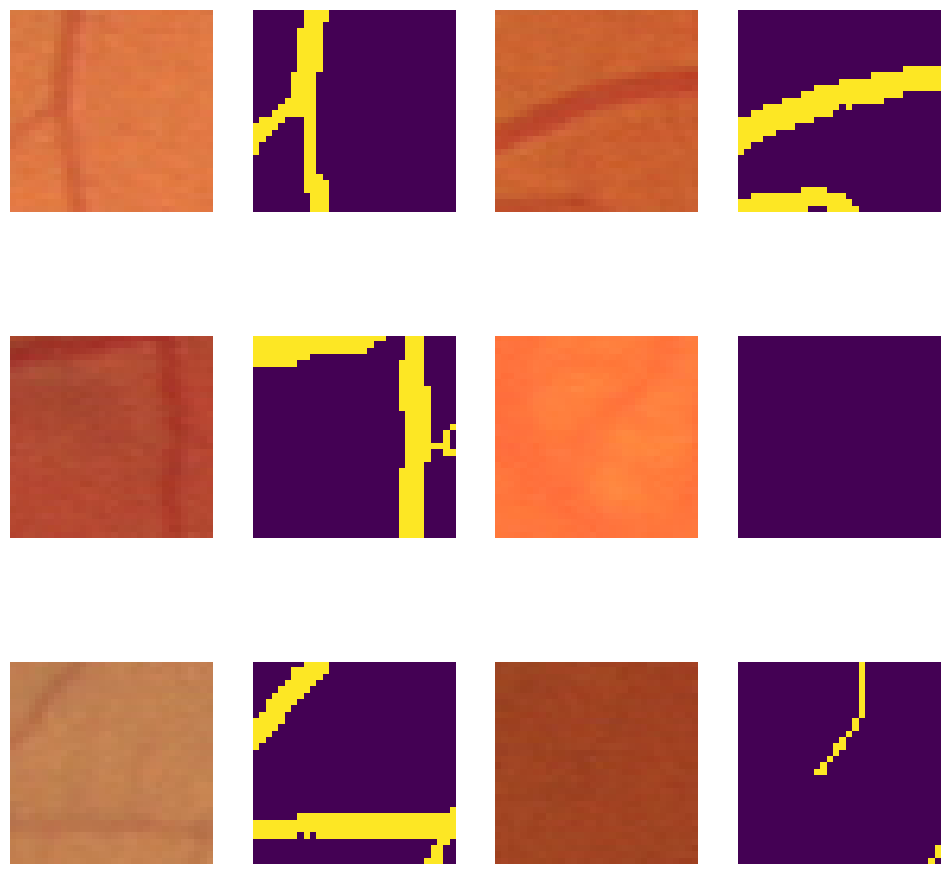

In [6]:
from unet_utils import extract_patches, preprocessing

# work with 32x32 patches
patch_size = (32, 32)

# 200 patches per image
patches_per_im = 200

# visualize a couple of patches as a visual check
patches, patches_segmentations = extract_patches(train_images, train_segmentations, patch_size, patches_per_im=1, seed=7)

print(patches.shape)

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 12))

for i in range(0, 3):
    axes[i, 0].axis('off')
    axes[i, 0].imshow(patches[i])
    axes[i, 1].axis('off')
    axes[i, 1].imshow(patches_segmentations[i][:, :, 0])
    axes[i, 2].axis('off')
    axes[i, 2].imshow(patches[i+5])
    axes[i, 3].axis('off')
    axes[i, 3].imshow(patches_segmentations[i+5][:, :, 0])

plt.show()

In [7]:
# pad the validation data to fit the U-Net model
# images of shape (584, 565) shape result in concatenation error due to the odd number of columns

print("Old shape:", val_images.shape)

val_images, val_masks, val_segmentations = preprocessing(
    val_images, 
    val_masks, 
    val_segmentations, 
    desired_shape=(584, 584))
    
print("New shape:", val_images.shape)

Old shape: (4, 584, 565, 3)
New shape: (4, 584, 584, 3)


In [8]:
import os
from unet_model import unet
from unet_utils import datagenerator
from keras.models import load_model
from keras.optimizers import Adam, SGD
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# use a single training image, to better demonstrate the effects of data augmentation
X_train, y_train = np.expand_dims(train_images[0], axis=0), np.expand_dims(train_segmentations[0], axis=0)

print(X_train.shape)
print(y_train.shape)

# hyperparameters
depth = 3
channels = 32
use_batchnorm = True
batch_size = 64
epochs = 250
steps_per_epoch = int(np.ceil((patches_per_im * len(train_images)) / batch_size))

# work with 32x32 patches
patch_size = (32, 32)
# 200 patches per image
patches_per_im = 200

# initialize model
model = unet(input_shape=(None, None, 3), depth=depth, channels=channels, batchnorm=use_batchnorm)

# print a summary of the model
# model.summary(line_length=120)

# compile the model
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# stop the training if the validation loss does not increase for 15 consecutive epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# train the model with the data generator, and save the training history
history = model.fit(datagenerator(X_train, y_train, patch_size, patches_per_im, batch_size),
                              validation_data=(val_images, val_segmentations),
                              steps_per_epoch=steps_per_epoch, epochs=epochs, verbose=2,
                              callbacks=[early_stopping])

(1, 584, 565, 3)
(1, 584, 565, 1)
Epoch 1/250
50/50 - 53s - 1s/step - accuracy: 0.8037 - loss: 0.5430 - val_accuracy: 0.9136 - val_loss: 0.4480
Epoch 2/250
50/50 - 40s - 806ms/step - accuracy: 0.9421 - loss: 0.3449 - val_accuracy: 0.9136 - val_loss: 0.3186
Epoch 3/250
50/50 - 40s - 809ms/step - accuracy: 0.9533 - loss: 0.2481 - val_accuracy: 0.7091 - val_loss: 0.5197
Epoch 4/250
50/50 - 39s - 786ms/step - accuracy: 0.9548 - loss: 0.1944 - val_accuracy: 0.9139 - val_loss: 0.4164
Epoch 5/250
50/50 - 44s - 885ms/step - accuracy: 0.9576 - loss: 0.1600 - val_accuracy: 0.8913 - val_loss: 0.4230
Epoch 6/250
50/50 - 41s - 813ms/step - accuracy: 0.9596 - loss: 0.1410 - val_accuracy: 0.9139 - val_loss: 0.3397
Epoch 7/250
50/50 - 41s - 812ms/step - accuracy: 0.9598 - loss: 0.1313 - val_accuracy: 0.9153 - val_loss: 0.3213
Epoch 8/250
50/50 - 41s - 810ms/step - accuracy: 0.9630 - loss: 0.1166 - val_accuracy: 0.9147 - val_loss: 0.3124
Epoch 9/250
50/50 - 36s - 714ms/step - accuracy: 0.9646 - loss: 0

### Visualizing the segmentation results

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


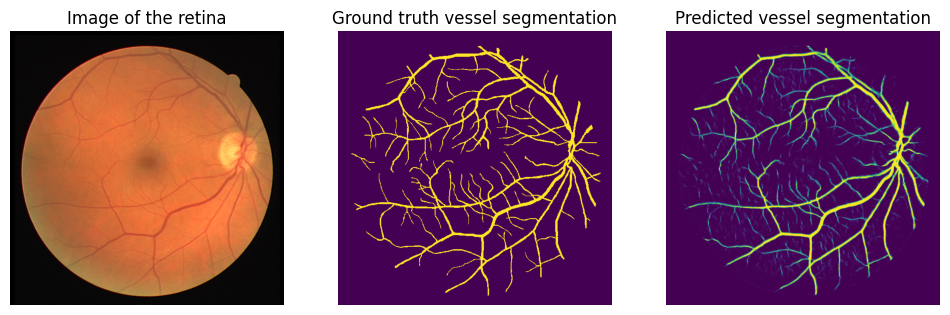

In [9]:
# run the model on one test image and show the results
from unet_utils import preprocessing

# test data paths
impaths_test = glob(data_folder + 'test/images/*.tif')

# load data
test_images, test_masks, test_segmentations = load_data(impaths_test, test=True)

# pad the data to fit the U-Net model
test_images, test_masks, test_segmentations = preprocessing(test_images, test_masks, test_segmentations, 
                                                            desired_shape=(584, 584))

# use a single image to evaluate
X_test, y_test = np.expand_dims(test_images[0], axis=0), np.expand_dims(test_masks[0], axis=0)

# predict test samples
test_prediction = model.predict(X_test, batch_size=4)

# visualize the test result
plt.figure(figsize=(12, 10))

plt.subplot(1, 3, 1)
plt.title("Image of the retina")
plt.axis('off')
plt.imshow(test_images[0])

plt.subplot(1, 3, 2)
plt.title("Ground truth vessel segmentation")
plt.axis('off')
plt.imshow(test_segmentations[0][:, :, 0])

plt.subplot(1, 3, 3)
plt.title("Predicted vessel segmentation")
plt.axis('off')
plt.imshow(test_prediction[0, :, :, 0])

plt.show()

# Exercises

## Number of parameters

The first convolutional layer in the MNIST example has 320 parameters. The first fully connected layer has 1179,776 parameters. What do these parameters correspond to? 

<font color='#770a0a'>What is the general expression for the number of parameters of 1) a convolutional layer and 2) a fully-connected layer?</font>

## Fully-convolutional MNIST model

Modify the model in the MNIST example in such a way that it only contains convolutional layers while keeping the same number of parameters. If you do the modification correctly, the two models will have the same behaviour (i.e. they will represent the same model, only with different implementation). Show this experimentally. 


## U-Net architecture

<font color='#770a0a'> What is the role of the skip connections in the U-Net neural network architecture? Will it be possible to train the exact same architecture with the skip connections omitted? If yes, what would be the expected result? If no, what would be the cause of the error?</font>

## Data augmentation

<font color='#770a0a'>Why does data augmentation result in less overfitting? Can data augmentation be applied to the test samples? If yes, towards what goal? If no, what is preventing that?</font>


Implement random brightness augmentation of the image data by adding a random offset to the image intensity before passing them trough the network at training time. Train a model with random brightness augmentation and compare it to the baseline above. 

Implement data augmentation procedure that in addition to brightness augmentation also performs b-spline geometric augmentation using the [`gryds`](https://github.com/tueimage/gryds) package (you can look at the documentation of the package for an example on how to do that). Compare the new model with the baseline and the model that only performs brightness augmentation.



### Number of parameters
***SOLUTION:***

These parameters correspond to the weights learnt during training.

The number of parameters in a convolutional layer is:
$$p_{conv} = K_w\cdot K_h \cdot C_{in}\cdot C_{out} + C_{out}$$
, where $K_w$ and $K_h$ are the kernel widht and height respectively and $C_{in}$ and $C_{out}$ are the input and output channels repectively.

The number of parameters in a fully-connected layer (dense) is:
$$p_{fully} = N_{in}\cdot N_{out} + N_{out}$$
, where $N_{in}$ and $N_{out}$ are the input and output channels respectively.

### Fully-convolutional MNIST model
***SOLUTION:***

In [11]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from keras.losses import categorical_crossentropy
from keras.optimizers import Adam

# We substitue the model to contain convolutional layers
modf = Sequential()
# same as original
modf.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
# added stride to accomplish max pooling effect
modf.add(Conv2D(64, (3, 3),(2,2), activation='relu',))
# drop out can stay? cannot be incorporate into Conv2D layer
modf.add(Dropout(0.25))
# calculated kernel size based on same 128 output channels
modf.add(Conv2D(128, (12,12), activation='relu'))
# drop out can stay again?
modf.add(Dropout(0.5))
# calculated kernel size based on same 10 output channels
modf.add(Conv2D(10, (1,1), activation='softmax'))
# flatten so compatible with y-targets
modf.add(Flatten())

modf.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 1, 1, 128)      │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 1, 1, 10)       │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from keras.losses import categorical_crossentropy
from keras.optimizers import Adam

# load the MNIST the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# scale the image intensities to the 0-1 range
x_train = (x_train / 255.0).astype(np.float32)
x_test = (x_test / 255.0).astype(np.float32)

# convert the data to channel-last
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# convert the labels to one-hot encoded
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

modf.compile(loss=categorical_crossentropy, optimizer=Adam(), metrics=['accuracy'])

modf.fit(x_train, y_train,
          batch_size=128,
          epochs=12,
          verbose=1,
          validation_data=(x_test, y_test))

score = modf.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 178ms/step - accuracy: 0.9221 - loss: 0.2602 - val_accuracy: 0.9802 - val_loss: 0.0649
Epoch 2/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 208ms/step - accuracy: 0.9706 - loss: 0.0971 - val_accuracy: 0.9864 - val_loss: 0.0424
Epoch 3/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 194ms/step - accuracy: 0.9780 - loss: 0.0733 - val_accuracy: 0.9869 - val_loss: 0.0397
Epoch 4/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 86s 184ms/step - accuracy: 0.9816 - loss: 0.0598 - val_accuracy: 0.9888 - val_loss: 0.0347
Epoch 5/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 190ms/step - accuracy: 0.9842 - loss: 0.0502 - val_accuracy: 0.9896 - val_loss: 0.0314
Epoch 6/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 193ms/step - accuracy: 0.9865 - loss: 0.0432 - val_accuracy: 0.9893 - val_loss: 0.0326
Epoch 7/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 215ms/step - accuracy: 0.9869 - loss: 0.0396 - val_accuracy: 0.9895 - val_loss: 0.0359
Epoch 8/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - accuracy: 0.9893 - loss: 

The training and validation accuracy and loss are very similar to the not-convolutional-only model, indicating a similar performance. Interestingly the epoch time seems to have increased substantially even thought the amount of parameters is identical.

### U-Net architecture
***SOLUTION:***

The skip connections part of U-Net neural network architecture combines the featuremap from the encoder with the feature map of the decorder, this happens at every layer in the U-net. It is possible to train the exact same architecture with the skip connections omitted but this will make the decoder work with only very abstract features and the spatial precision will be bad.


### Data augmentation
***SOLUTION:***

Data augmentation is a procedure where \"fake\" samples are created and added to the original data set. This results in less overfitting because the network will focus less on minor details and more on important features because there is more diversity in the data set. Data augmentation cannot be applied to the test samples because the test samples should respresent the real world, where data augmentation creates \"fake\" samples.

## Brightness Augmentation


In [13]:
#### INTENSITY ####
%matplotlib inline
import sys
sys.path.append('code/')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from glob import glob
from unet_utils import load_data

# location of the DRIVE dataset
data_folder = 'data/DRIVE/'
train_paths = glob(data_folder + 'training/images/*.tif')
images, masks, segmentations = load_data(train_paths)

# divide in training and validation
train_images, val_images, train_masks, val_masks, train_segmentations, val_segmentations = train_test_split(
    images, masks, segmentations, test_size=0.2, random_state=7)

from unet_utils import extract_patches, preprocessing

# work with 32x32 patches
patch_size = (32, 32)

# 200 patches per image
patches_per_im = 200

# visualize a couple of patches as a visual check
patches, patches_segmentations = extract_patches(train_images, train_segmentations, patch_size, patches_per_im=1, seed=7)

# pad the validation data to fit the U-Net model
# images of shape (584, 565) shape result in concatenation error due to the odd number of columns

val_images, val_masks, val_segmentations = preprocessing(
    val_images, 
    val_masks, 
    val_segmentations, 
    desired_shape=(584, 584))

import os
from unet_model import unet
from unet_utils import datagenerator
from keras.models import load_model
from keras.optimizers import Adam, SGD
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

**Augment the sample**

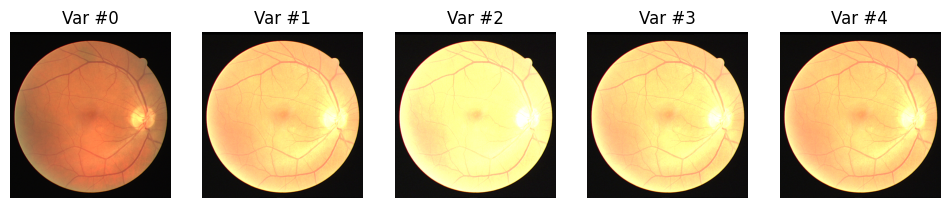

In [15]:
# use a single training image, to better demonstrate the effects of data augmentation
X_train, y_train = np.expand_dims(train_images[0], axis=0), np.expand_dims(train_segmentations[0], axis=0)

# fix the random seed for reproducability
np.random.seed(0)

# create N augmented samples
rBias = 0.1
rMax = 2.5

N_bri = 5
for n in range(N_bri):
    rFac = np.random.uniform(0.3,3)
    X_train_bri = X_train[0,:,:,:]*rFac
    X_train_bri = np.clip(X_train_bri, 0, 1)
    y_train_bri = y_train[0,:,:,:]
    X_train = np.append(X_train,X_train_bri[np.newaxis,:,:,:],axis=0)
    y_train = np.append(y_train,y_train_bri[np.newaxis,:,:,:],axis=0)

# visualize augmentation
# visualize the test result
plt.figure(figsize=(12, 10))

for n in range(N_bri+1):
    plt.subplot(1,N_bri,n+1)
    plt.title("Var #" + str(n))
    plt.axis('off')
    plt.imshow(X_train[n])

**Train the model**

In [16]:
# hyperparameters
depth = 3
channels = 32
use_batchnorm = True
batch_size = 64
epochs = 250
steps_per_epoch = int(np.ceil((patches_per_im * len(train_images)) / batch_size))

# work with 32x32 patches
patch_size = (32, 32)
# 200 patches per image
patches_per_im = 200

# initialize model
model = unet(input_shape=(None, None, 3), depth=depth, channels=channels, batchnorm=use_batchnorm)

# print a summary of the model
# model.summary(line_length=120)

# compile the model
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# stop the training if the validation loss does not increase for 15 consecutive epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
# train the model with the data generator, and save the training history
history = model.fit(datagenerator(X_train, y_train, patch_size, patches_per_im, batch_size),
                              validation_data=(val_images, val_segmentations),
                              steps_per_epoch=steps_per_epoch, epochs=epochs, verbose=2,
                              callbacks=[early_stopping])

Epoch 1/250
50/50 - 53s - 1s/step - accuracy: 0.8057 - loss: 0.5430 - val_accuracy: 0.9136 - val_loss: 0.4864
Epoch 2/250
50/50 - 41s - 817ms/step - accuracy: 0.9480 - loss: 0.3304 - val_accuracy: 0.9136 - val_loss: 0.2939
Epoch 3/250
50/50 - 41s - 830ms/step - accuracy: 0.9563 - loss: 0.2280 - val_accuracy: 0.9136 - val_loss: 0.2936
Epoch 4/250
50/50 - 41s - 822ms/step - accuracy: 0.9622 - loss: 0.1683 - val_accuracy: 0.9136 - val_loss: 0.3023
Epoch 5/250
50/50 - 41s - 817ms/step - accuracy: 0.9642 - loss: 0.1380 - val_accuracy: 0.9136 - val_loss: 0.3396
Epoch 6/250
50/50 - 41s - 826ms/step - accuracy: 0.9646 - loss: 0.1238 - val_accuracy: 0.9143 - val_loss: 0.3631
Epoch 7/250
50/50 - 44s - 876ms/step - accuracy: 0.9626 - loss: 0.1183 - val_accuracy: 0.9162 - val_loss: 0.3103
Epoch 8/250
50/50 - 41s - 817ms/step - accuracy: 0.9655 - loss: 0.1042 - val_accuracy: 0.9158 - val_loss: 0.3422
Epoch 9/250
50/50 - 41s - 820ms/step - accuracy: 0.9653 - loss: 0.1019 - val_accuracy: 0.9222 - val

**Visulation of results**

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


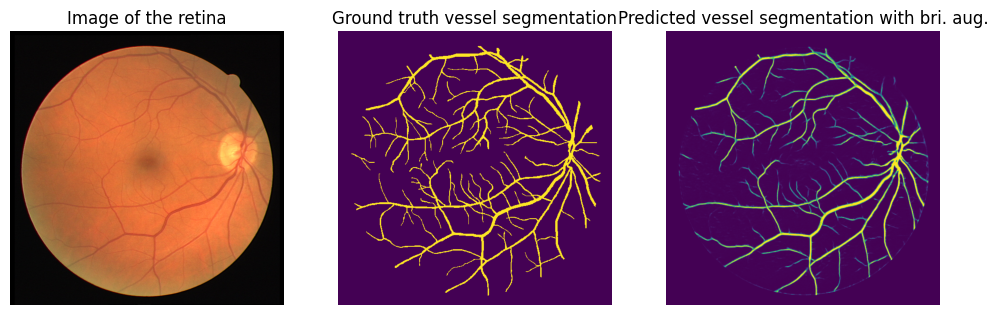

In [17]:
# run the model on one test image and show the results
from unet_utils import preprocessing

# test data paths
impaths_test = glob(data_folder + 'test/images/*.tif')

# load data
test_images, test_masks, test_segmentations = load_data(impaths_test, test=True)

# pad the data to fit the U-Net model
test_images, test_masks, test_segmentations = preprocessing(test_images, test_masks, test_segmentations, 
                                                            desired_shape=(584, 584))

# use a single image to evaluate
X_test, y_test = np.expand_dims(test_images[0], axis=0), np.expand_dims(test_masks[0], axis=0)

# predict test samples
test_prediction = model.predict(X_test, batch_size=4)

# visualize the test result
plt.figure(figsize=(12, 10))

plt.subplot(1, 3, 1)
plt.title("Image of the retina")
plt.axis('off')
plt.imshow(test_images[0])

plt.subplot(1, 3, 2)
plt.title("Ground truth vessel segmentation")
plt.axis('off')
plt.imshow(test_segmentations[0][:, :, 0])

plt.subplot(1, 3, 3)
plt.title("Predicted vessel segmentation with bri. aug.")
plt.axis('off')
plt.imshow(test_prediction[0, :, :, 0])

plt.show()

**CONCLUSION:** 

Compared to the baseline (non-augmented) model, the model trained with random brightness augmentation exhibits slower initial convergence, as expected when additional variability is introduced into the training data. However, the augmented model shows significantly smoother validation curves, indicating increased robustness and reduced sensitivity to data fluctuations. Furthermore, the augmented model experiences less overfitting — the training and validation losses remain closely aligned throughout training.


Although both models ultimately achieve comparable peak validation accuracy (around 95–96%), the augmented model’s stability and consistency suggest it generalizes better to unseen data. Therefore, random brightness augmentation leads to a more reliable and robust model, even if convergence is slower.

### B-Spline + Brightness Augmentation
**Augment the sample**

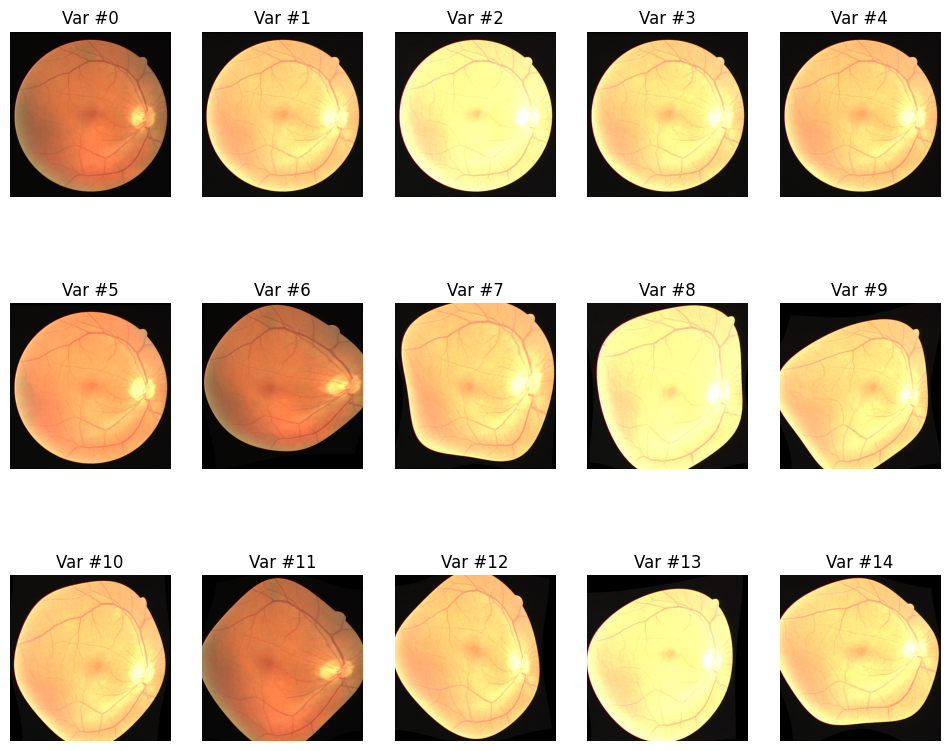

In [28]:
#### B-SPLINE + INTENSITY ####
import gryds

# fix seed for reproductability
np.random.seed(0)

# gryds transformation
N_gryds = 3
for n in range(N_gryds):
    for i in range(N_bri):        
        X_train_gryds = X_train[i,:,:,:].copy()
        y_train_gryds = y_train[i,:,:,:].copy()

        # Define a random 10x10 B-spline grid for a 2D image:
        random_grid = np.random.rand(2, 10, 10)
        random_grid -= 0.5
        random_grid /= 10

        # Define a B-spline transformation object
        bspline = gryds.BSplineTransformation(random_grid)
        
        # Transform the image using the B-spline transformation
        # gryds only does 1 channel per time
        for c in range(3):
            # Define an interpolator object for the image:
            interpolatorx = gryds.Interpolator(X_train_gryds[:,:,c])
            X_train_gryds[:,:,c] = interpolatorx.transform(bspline)
        interpolatory = gryds.Interpolator(y_train[0,:,:,0], order=0)
        y_train_gryds = interpolatory.transform(bspline)

        X_train_gryds = np.clip(X_train_gryds, 0, 1)
        
        X_train = np.append(X_train,X_train_gryds[np.newaxis,:,:,:],axis=0)
        y_train = np.append(y_train,y_train_gryds[np.newaxis,:,:,np.newaxis],axis=0)

# visualize augmentation
# visualize the test result
plt.figure(figsize=(12, 10))

for n in range(N_gryds*N_bri):
    plt.subplot(N_gryds,N_bri,n+1)
    plt.title("Var #" + str(n))
    plt.axis('off')
    plt.imshow(X_train[n])

**Train the model**

In [29]:
# hyperparameters
depth = 3
channels = 32
use_batchnorm = True
batch_size = 64
epochs = 250
steps_per_epoch = int(np.ceil((patches_per_im * len(train_images)) / batch_size))

# work with 32x32 patches
patch_size = (32, 32)
# 200 patches per image
patches_per_im = 200

# initialize model
model = unet(input_shape=(None, None, 3), depth=depth, channels=channels, batchnorm=use_batchnorm)

# print a summary of the model
# model.summary(line_length=120)

# compile the model
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# stop the training if the validation loss does not increase for 15 consecutive epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
# train the model with the data generator, and save the training history
history = model.fit(datagenerator(X_train, y_train, patch_size, patches_per_im, batch_size),
                              validation_data=(val_images, val_segmentations),
                              steps_per_epoch=steps_per_epoch, epochs=epochs, verbose=2,
                              callbacks=[early_stopping])

Epoch 1/250
50/50 - 55s - 1s/step - accuracy: 0.8086 - loss: 0.5517 - val_accuracy: 0.9136 - val_loss: 0.3275
Epoch 2/250
50/50 - 43s - 851ms/step - accuracy: 0.9386 - loss: 0.3539 - val_accuracy: 0.9136 - val_loss: 0.2754
Epoch 3/250
50/50 - 43s - 852ms/step - accuracy: 0.9508 - loss: 0.2583 - val_accuracy: 0.9136 - val_loss: 0.3124
Epoch 4/250
50/50 - 43s - 854ms/step - accuracy: 0.9512 - loss: 0.2001 - val_accuracy: 0.9136 - val_loss: 0.3261
Epoch 5/250
50/50 - 43s - 854ms/step - accuracy: 0.9538 - loss: 0.1790 - val_accuracy: 0.9136 - val_loss: 0.3361
Epoch 6/250
50/50 - 43s - 856ms/step - accuracy: 0.9559 - loss: 0.1491 - val_accuracy: 0.9136 - val_loss: 0.3792
Epoch 7/250
50/50 - 43s - 854ms/step - accuracy: 0.9593 - loss: 0.1308 - val_accuracy: 0.9138 - val_loss: 0.4010
Epoch 8/250
50/50 - 43s - 858ms/step - accuracy: 0.9611 - loss: 0.1215 - val_accuracy: 0.9143 - val_loss: 0.3832
Epoch 9/250
50/50 - 45s - 895ms/step - accuracy: 0.9616 - loss: 0.1163 - val_accuracy: 0.9153 - val

**Visulation of results**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


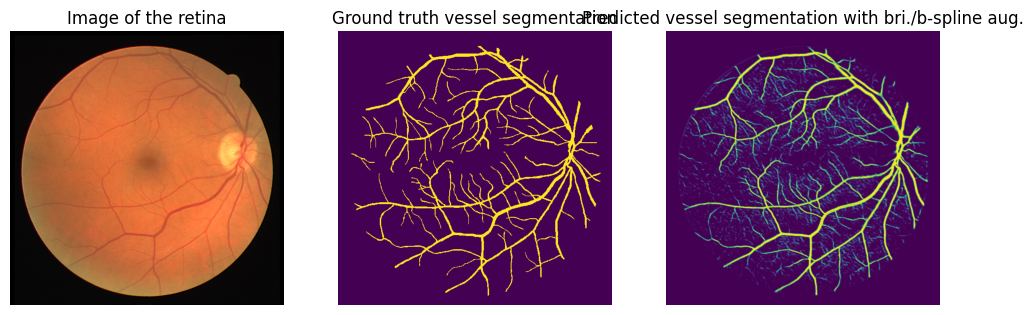

In [30]:
# run the model on one test image and show the results
from unet_utils import preprocessing

# test data paths
impaths_test = glob(data_folder + 'test/images/*.tif')

# load data
test_images, test_masks, test_segmentations = load_data(impaths_test, test=True)

# pad the data to fit the U-Net model
test_images, test_masks, test_segmentations = preprocessing(test_images, test_masks, test_segmentations, 
                                                            desired_shape=(584, 584))

# use a single image to evaluate
X_test, y_test = np.expand_dims(test_images[0], axis=0), np.expand_dims(test_masks[0], axis=0)

# predict test samples
test_prediction = model.predict(X_test, batch_size=4)

# visualize the test result
plt.figure(figsize=(12, 10))

plt.subplot(1, 3, 1)
plt.title("Image of the retina")
plt.axis('off')
plt.imshow(test_images[0])

plt.subplot(1, 3, 2)
plt.title("Ground truth vessel segmentation")
plt.axis('off')
plt.imshow(test_segmentations[0][:, :, 0])

plt.subplot(1, 3, 3)
plt.title("Predicted vessel segmentation with bri./b-spline aug.")
plt.axis('off')
plt.imshow(test_prediction[0, :, :, 0])

plt.show()

**CONCLUSION:** 

The model trained with combined B-spline and intensity augmentation showed clear improvements in both learning stability and generalization compared to the reference and brightness-only models. Training accuracy rose steadily from ~81% to ~97%, while validation accuracy reached up to 96%, with a minimum validation loss around 0.11.

Unlike the reference model, which plateaued early, and the brightness-only model, which tended to oversmooth outputs, the B-spline–augmented model maintained strong validation performance throughout training and achieved finer structural representation in predictions. The verification images were slightly noisier but exhibited more distinct details and sharper boundaries.

Overall, the results suggest that adding controlled B-spline geometric transformations to intensity augmentation yields richer spatial generalization and more detailed reconstructions, outperforming both baseline and brightness-only augmentation setups.